In [1]:
!pip install -q diffusers transformers accelerate

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU nahi mila. Colab mein Runtime > Change runtime type > GPU select karo.")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Diffusion model loaded successfully!")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Diffusion model loaded successfully!


  0%|          | 0/30 [00:00<?, ?it/s]

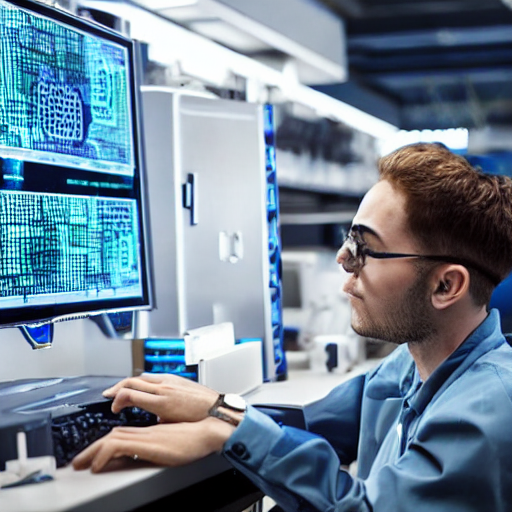

In [4]:
prompt = "a realistic futuristic AI engineer working on a computer in a modern laboratory"

image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

display(image)

Generating: a futuristic AI laboratory


  0%|          | 0/25 [00:00<?, ?it/s]

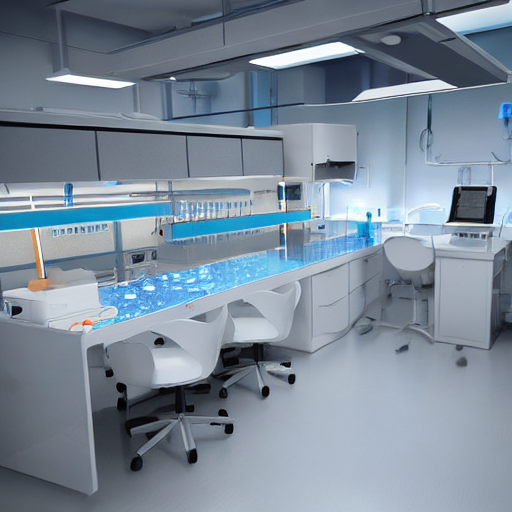

Saved: diffusion_image_1.png
Generating: a robot doctor analyzing a medical scan


  0%|          | 0/25 [00:00<?, ?it/s]

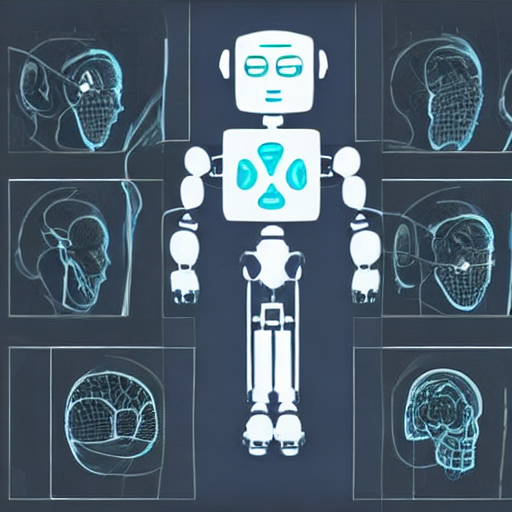

Saved: diffusion_image_2.png
Generating: a self driving car on a modern highway


  0%|          | 0/25 [00:00<?, ?it/s]

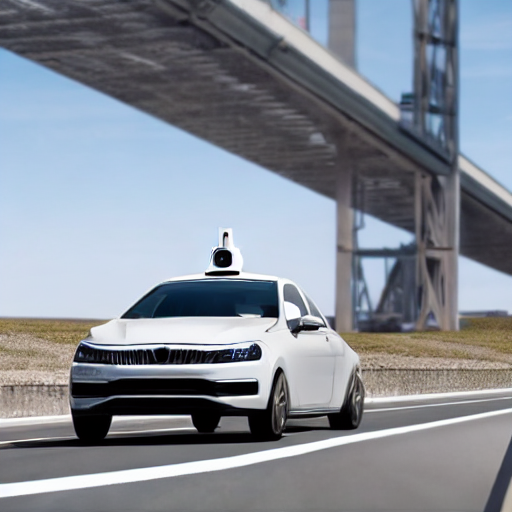

Saved: diffusion_image_3.png
Generating: a beautiful mountain landscape at sunset


  0%|          | 0/25 [00:00<?, ?it/s]

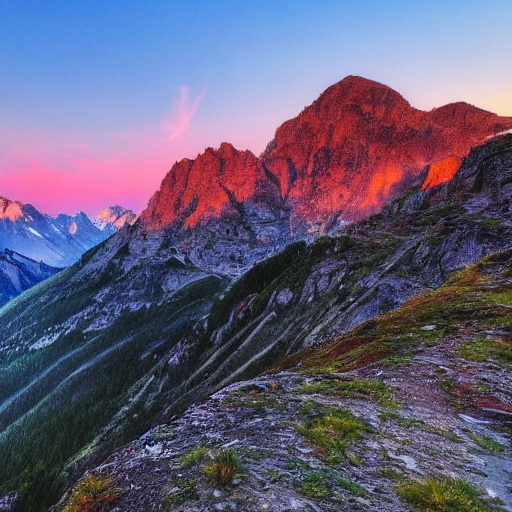

Saved: diffusion_image_4.png


In [6]:
prompts = [
    "a futuristic AI laboratory",
    "a robot doctor analyzing a medical scan",
    "a self driving car on a modern highway",
    "a beautiful mountain landscape at sunset"
]

for i, prompt in enumerate(prompts):

    print("Generating:", prompt)

    image = pipe(
        prompt,
        num_inference_steps=25,
        guidance_scale=7.5
    ).images[0]

    # Image display
    display(image)

    # Image save
    filename = f"diffusion_image_{i+1}.png"
    image.save(filename)

    print("Saved:", filename)